In [4]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import shap

In [5]:
df = pd.read_csv("../data/processed/telco_clean.csv")

X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [6]:
best_pipeline = joblib.load(
    "../models/churn_model.pkl"
)

In [7]:
best_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['customerID','gender','SeniorCitizen',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [8]:
model = best_pipeline.named_steps["model"]

In [9]:
preprocessor = best_pipeline.named_steps["preprocessor"]

In [10]:
X_processed = preprocessor.transform(X)

In [11]:
feature_names = preprocessor.get_feature_names_out()

In [12]:
X_processed = pd.DataFrame(
    X_processed,
    columns=feature_names
)

ValueError: Shape of passed values is (7032, 1), indices imply (7032, 5670)

In [13]:
importance = pd.DataFrame({

    "Feature":feature_names,

    "Coefficient":model.coef_[0]

})

In [14]:
importance["Importance"] = abs(
    importance["Coefficient"]
)

In [15]:
importance = importance.sort_values(

"Importance",

ascending=False

)

In [16]:
importance.head(15)

,Feature,Coefficient,Importance
1,num__tenure,-1.306275,1.306275
332,cat__customerID_0607-DAAHE,0.977495,0.977495
3575,cat__customerID_6323-AYBRX,0.977352,0.977352
1959,cat__customerID_3512-IZIKN,0.971121,0.971121
565,cat__customerID_1043-YCUTE,0.968315,0.968315
3699,cat__customerID_6532-YLWSI,0.967292,0.967292
4870,cat__customerID_8631-NBHFZ,0.965841,0.965841
4173,cat__customerID_7359-SSBJK,0.961735,0.961735
4838,cat__customerID_8580-QVLOC,0.961656,0.961656
5110,cat__customerID_9063-ZGTUY,0.954506,0.954506


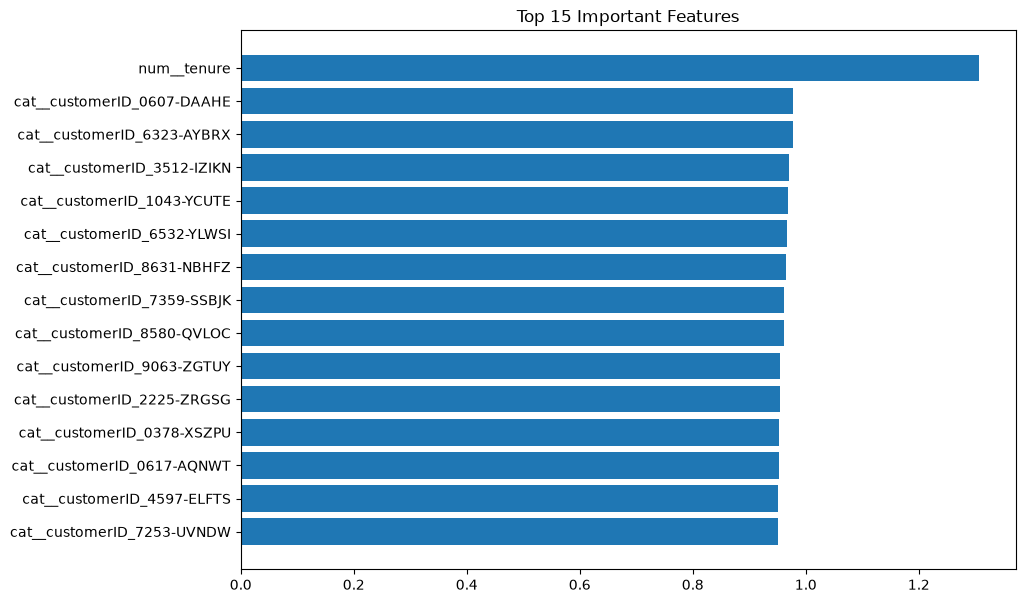

In [17]:
plt.figure(figsize=(10,7))

plt.barh(

importance["Feature"][:15],

importance["Importance"][:15]

)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [18]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
X_processed = X_processed.toarray()

X_processed = pd.DataFrame(
    X_processed,
    columns=feature_names
)

In [25]:
shap_values = explainer(X_processed)

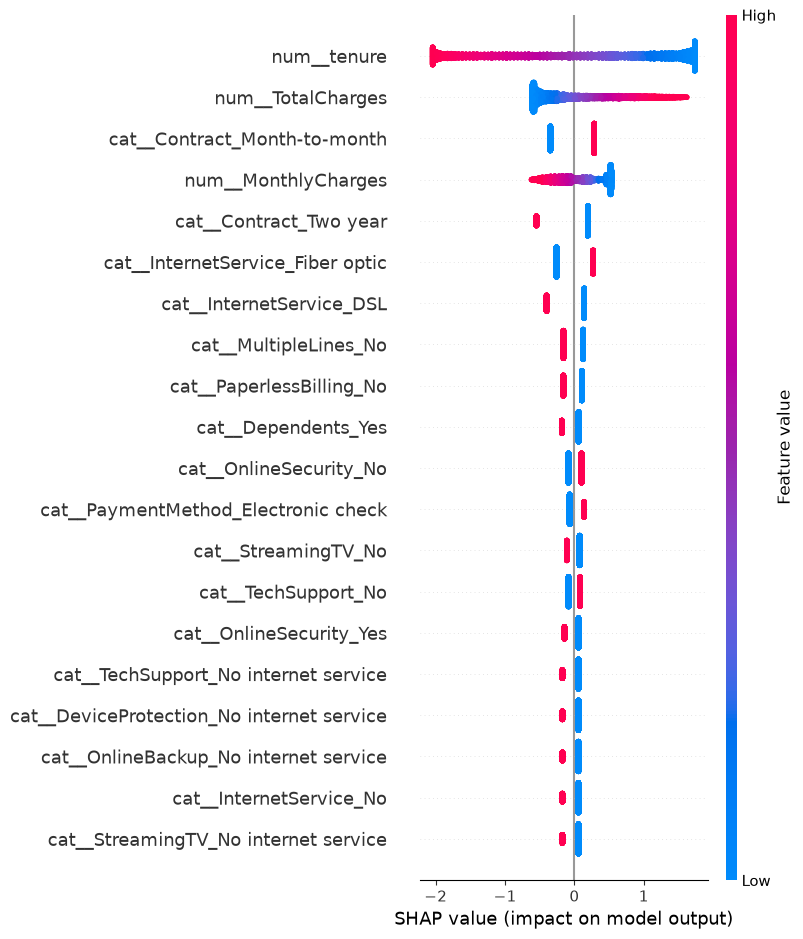

In [26]:
shap.summary_plot(
    shap_values,
    X_processed
)

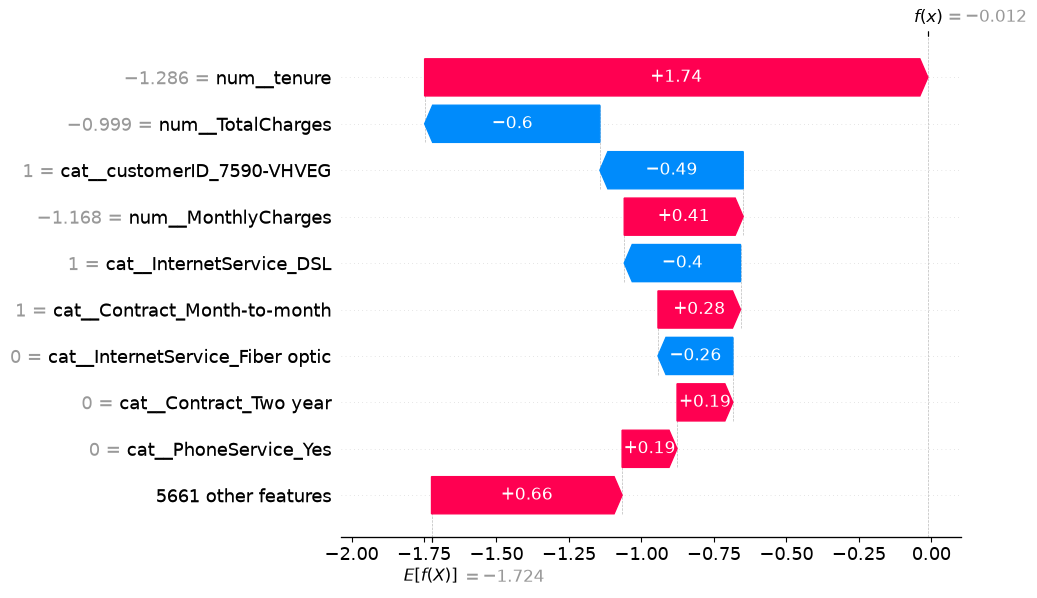

In [27]:
shap.plots.waterfall(
    shap_values[0]
)

In [28]:
print(len(feature_names))

5670
